# Réalisation du plan d'expérience du recuit simulé

Ce plan d'expérience suit le plan suivant :
1. Définition des paramètres globaux
2. Étude de trajectoire
3. Étude de l'influence des paramètres
4. Définition des paramètres optimisés
5. Statistiques qualité des solutions
6. Distance à la borne inférieure
7. Conclusion

## 1. Définition des paramètres globaux

Nous allons réaliser l'étude statistique sur les paramètres suivants :
- $N = \{10, 12, 15, 17, 20, 22, 25, 30\}$ : nombre de sommets
- `NB_SEEDS = 10` : nombre d'instances (seeds) par taille
- `NB_ITERATIONS = 5` : nombre d'exécutions du recuit par instance

L'objectif est d'itérer sur les mêmes graphes entre algorithmes. On fixe donc un `seed` par instance de graphe.
On calcule une borne inférieure « min-sortants » de chaque graphe pour obtenir un `gap` comparable entre algorithmes.

### Sorties attendues

Pour chaque taille $N$ :
- meilleur coût, moyenne, médiane, écart-type, min, max
- `gap_mean` et `gap_std` par rapport à la borne inférieure
- meilleurs paramètres $(\alpha, \text{max\_iter})$ retenus

### Graphiques produits
- Trajectoire du recuit (coût courant / meilleur coût / température)
- Heatmap à double entrée $(\alpha, \text{max\_iter})$ — tendance générale
- Gap et temps en fonction de $N$


In [92]:
import sys
import math
import time

import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../")

from graph_generator import generate_graph
from helper import is_tour_feasible, valid_next_nodes


### Paramètres globaux et génération des instances

- `N_VALUES` : tailles de graphe étudiées
- `NB_SEEDS` : nombre d'instances par taille (seed distinct) — pour itérer sur les mêmes graphes
- `NB_ITERATIONS` : nombre d'exécutions du recuit par instance


In [93]:
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 10
NB_ITERATIONS: int = 5


def get_standard_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph]]:
    """Génère `nb_seeds` graphes reproductibles de taille `n`, un par seed."""
    instances: list[tuple[int, nx.Graph]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        instances.append((seed, graph))
    return instances


### Borne de référence et gap

Borne inférieure « min-sortants » pour toutes les tailles : $\frac{1}{2} \sum_v \min_{u \neq v} w(v,u)$, arêtes interdites ($w = -1$) exclues.

$$\text{gap} = 100 \times \frac{\text{cost} - \text{reference}}{\text{reference}}$$


In [94]:
def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    """Borne inférieure : demi-somme des arêtes sortantes minimales (arêtes interdites exclues)."""
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    """Borne inférieure de référence pour le calcul du gap."""
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, reference: float) -> float:
    """Gap en % par rapport à la borne inférieure."""
    if reference <= 0:
        return float("inf")
    return 100.0 * (cost - reference) / reference


### Pré-calcul des instances et bornes

On matérialise `instances[n]` = liste de `(seed, graph, reference)` pour réutiliser les mêmes graphes et bornes dans toutes les études suivantes.


In [95]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in N_VALUES:
    raw: list[tuple[int, nx.Graph]] = get_standard_instances(n)
    enriched: list[tuple[int, nx.Graph, float]] = []
    for seed, graph in raw:
        ref: float = reference_value(graph)
        enriched.append((seed, graph, ref))
    instances[n] = enriched
    refs: list[float] = [r for _, _, r in enriched]
    print(f"N={n:3d} | {len(enriched)} instances | ref min={min(refs):.2f} max={max(refs):.2f}")


N= 10 | 10 instances | ref min=8.10 max=18.52
N= 12 | 10 instances | ref min=8.10 max=20.10
N= 15 | 10 instances | ref min=7.65 max=17.25
N= 17 | 10 instances | ref min=7.05 max=16.80
N= 20 | 10 instances | ref min=7.58 max=16.87
N= 22 | 10 instances | ref min=5.40 max=15.07
N= 25 | 10 instances | ref min=6.38 max=15.90
N= 30 | 10 instances | ref min=7.65 max=12.30


## 2. Étude de trajectoire

Objectif : visualiser la dynamique du recuit simulé sur une instance représentative ($N = 20$) — évolution du coût courant, du meilleur coût et de la température au fil des itérations.

On utilise ici une **variante instrumentée** `resolve_by_recuit_simule_traced` qui enregistre l'historique `(cost, best_cost, temperature)` à chaque itération.


In [96]:
# Implémentation inlinée du recuit (évite les imports relatifs du package algorithms)

def _tour_cost(graph: nx.Graph, tour: list[int]) -> float:
    total: float = 0.0
    for u, v in zip(tour, tour[1:]):
        weight: float = graph.edges[u, v]["weight"]
        if weight == -1:
            return float("inf")
        total += weight
    return total


def _is_feasible(graph: nx.Graph, tour: list[int]) -> bool:
    if len(tour) < 2 or tour[0] != tour[-1]:
        return False
    open_tour: list[int] = tour[:-1]
    if len(set(open_tour)) != len(open_tour):
        return False
    return is_tour_feasible(graph, open_tour)


def _two_opt_swap(tour: list[int], i: int, j: int) -> list[int]:
    return tour[:i] + tour[i:j + 1][::-1] + tour[j + 1:]


def _initial_tour(graph: nx.Graph, rng: np.random.Generator) -> list[int]:
    n: int = graph.number_of_nodes()
    visited: set[int] = {0}
    tour: list[int] = [0]
    while len(tour) < n:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)
        if not candidates:
            break
        next_node = min(candidates, key=lambda v: graph.edges[current, v]["weight"])
        tour.append(next_node)
        visited.add(next_node)
    tour.append(0)
    if _is_feasible(graph, tour):
        return tour
    for _ in range(50):
        order: list[int] = list(range(1, n))
        rng.shuffle(order)
        candidate: list[int] = [0] + order + [0]
        if _is_feasible(graph, candidate):
            return candidate
    return [0] + list(range(1, n)) + [0]


def _initial_temperature(graph: nx.Graph, tour: list[int], rng: np.random.Generator) -> float:
    n: int = len(tour)
    base_cost: float = _tour_cost(graph, tour)
    degradations: list[float] = []
    for _ in range(n * 20):
        i: int = int(rng.integers(1, n - 2))
        j: int = int(rng.integers(i + 1, n - 1))
        neighbor: list[int] = _two_opt_swap(tour, i, j)
        if not _is_feasible(graph, neighbor):
            continue
        delta: float = _tour_cost(graph, neighbor) - base_cost
        if delta > 0:
            degradations.append(delta)
        if len(degradations) >= 100:
            break
    if not degradations:
        return 1.0
    return -float(np.mean(degradations)) / math.log(0.8)


def resolve_by_recuit_simule(
    graph: nx.Graph,
    max_iterations: int = 10000,
    seed: int | None = None,
    alpha: float = 0.995,
) -> tuple[list[int], float]:
    """Recuit simulé standard (renvoie le meilleur tour et son coût)."""
    rng: np.random.Generator = np.random.default_rng(seed)
    current: list[int] = _initial_tour(graph, rng)
    current_cost: float = _tour_cost(graph, current)
    best: list[int] = list(current)
    best_cost: float = current_cost
    t: float = _initial_temperature(graph, current, rng)
    n: int = len(current)
    iteration: int = 0
    while iteration < max_iterations:
        neighbor: list[int] | None = None
        for _ in range(100):
            i: int = int(rng.integers(1, n - 2))
            j: int = int(rng.integers(i + 1, n - 1))
            candidate: list[int] = _two_opt_swap(current, i, j)
            if _is_feasible(graph, candidate):
                neighbor = candidate
                break
        if neighbor is None:
            break
        delta: float = _tour_cost(graph, neighbor) - current_cost
        if delta <= 0 or rng.random() < math.exp(-delta / t):
            current = neighbor
            current_cost += delta
            if current_cost < best_cost:
                best = list(current)
                best_cost = current_cost
        t *= alpha
        iteration += 1
    return best, best_cost


def resolve_by_recuit_simule_traced(
    graph: nx.Graph,
    max_iterations: int,
    seed: int | None,
    alpha: float,
) -> tuple[list[int], float, list[tuple[float, float, float]]]:
    """Variante instrumentée : renvoie aussi l'historique (cost, best_cost, temperature)."""
    rng: np.random.Generator = np.random.default_rng(seed)
    current: list[int] = _initial_tour(graph, rng)
    current_cost: float = _tour_cost(graph, current)
    best: list[int] = list(current)
    best_cost: float = current_cost
    t: float = _initial_temperature(graph, current, rng)
    n: int = len(current)
    history: list[tuple[float, float, float]] = [(current_cost, best_cost, t)]
    iteration: int = 0
    while iteration < max_iterations:
        neighbor: list[int] | None = None
        for _ in range(100):
            i: int = int(rng.integers(1, n - 2))
            j: int = int(rng.integers(i + 1, n - 1))
            candidate: list[int] = _two_opt_swap(current, i, j)
            if _is_feasible(graph, candidate):
                neighbor = candidate
                break
        if neighbor is None:
            break
        delta: float = _tour_cost(graph, neighbor) - current_cost
        if delta <= 0 or rng.random() < math.exp(-delta / t):
            current = neighbor
            current_cost += delta
            if current_cost < best_cost:
                best = list(current)
                best_cost = current_cost
        t *= alpha
        history.append((current_cost, best_cost, t))
        iteration += 1
    return best, best_cost, history


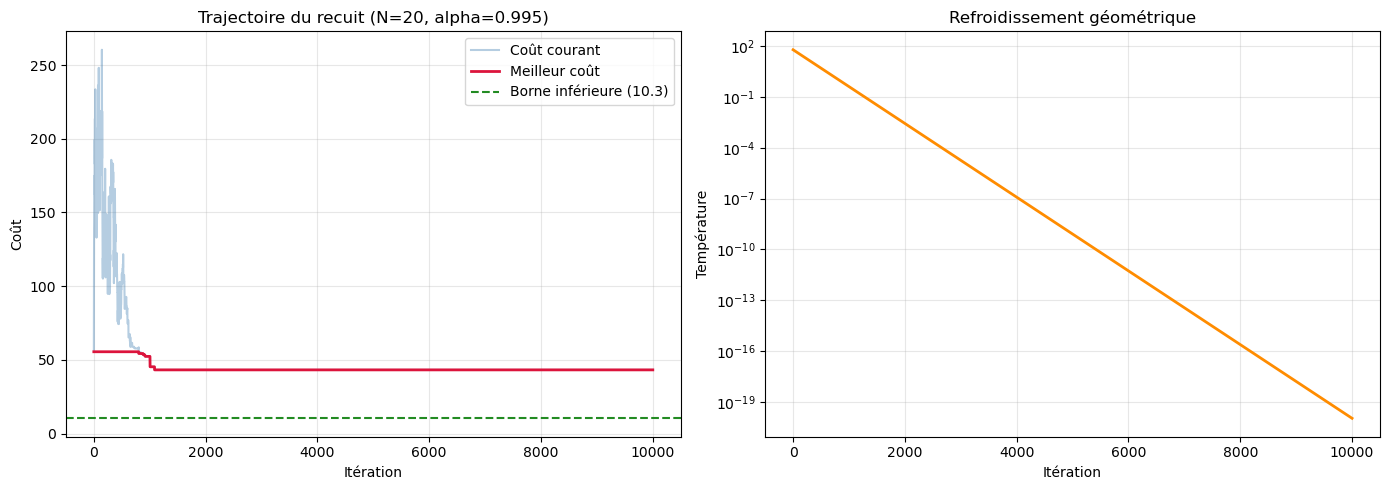

Coût final : 43.20
Borne : 10.35
Gap final : 317.39%


In [97]:
# Exécution d'une trace sur une instance N=20
TRACE_N = 20
TRACE_SEED_INSTANCE = 0
TRACE_SEED_ALGO = 2026
TRACE_ALPHA = 0.995
TRACE_MAX_ITER = 10000

_, trace_graph, trace_ref = instances[TRACE_N][TRACE_SEED_INSTANCE]

trace_tour, trace_best, trace_history = resolve_by_recuit_simule_traced(
    graph=trace_graph,
    max_iterations=TRACE_MAX_ITER,
    seed=TRACE_SEED_ALGO,
    alpha=TRACE_ALPHA,
)

history_df = pd.DataFrame(trace_history, columns=["cost", "best_cost", "temperature"])
history_df["iteration"] = range(len(history_df))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_df["iteration"], history_df["cost"], alpha=0.4, color="steelblue", label="Coût courant")
ax1.plot(history_df["iteration"], history_df["best_cost"], color="crimson", linewidth=2, label="Meilleur coût")
ax1.axhline(trace_ref, color="forestgreen", linestyle="--", label=f"Borne inférieure ({trace_ref:.1f})")
ax1.set_xlabel("Itération")
ax1.set_ylabel("Coût")
ax1.set_title(f"Trajectoire du recuit (N={TRACE_N}, alpha={TRACE_ALPHA})")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_df["iteration"], history_df["temperature"], color="darkorange", linewidth=2)
ax2.set_xlabel("Itération")
ax2.set_ylabel("Température")
ax2.set_title("Refroidissement géométrique")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Coût final : {trace_best:.2f}")
print(f"Borne : {trace_ref:.2f}")
print(f"Gap final : {100.0 * (trace_best - trace_ref) / trace_ref:.2f}%")


### Comparaison des trajectoires pour différentes tailles

Visualisation de la dynamique du recuit simulé pour 4 tailles représentatives ($N \in \{10, 15, 20, 30\}$), instance `seed=0`. On observe comment la capacité de convergence et l'écart à la borne inférieure varient avec $N$.

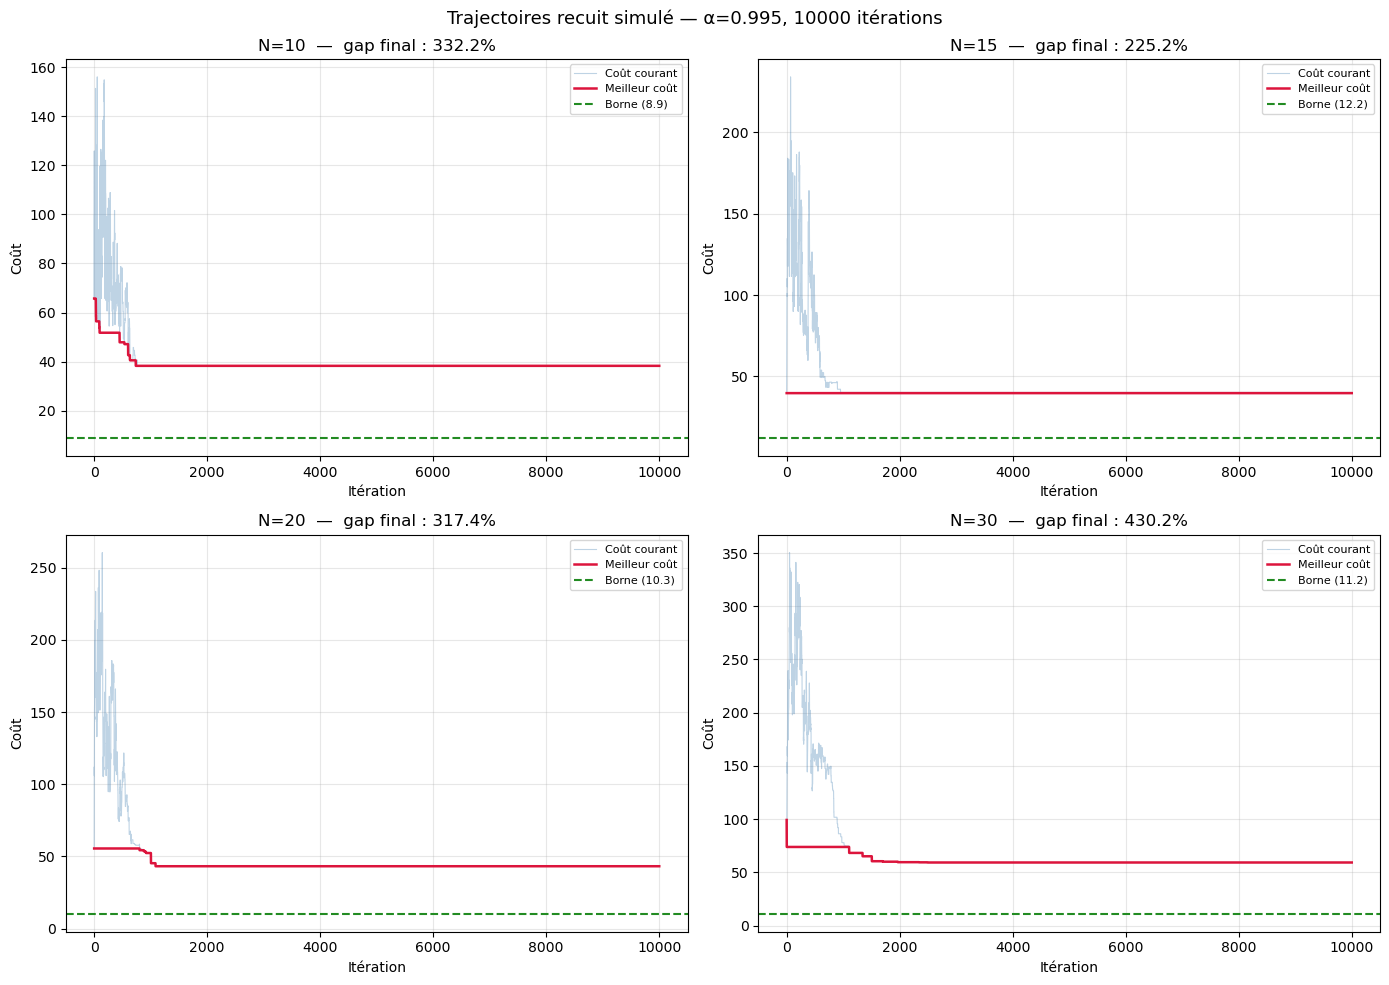

In [98]:
MULTI_N_SIZES = [10, 15, 20, 30]
MULTI_TRACE_ALPHA = 0.995
MULTI_TRACE_MAX_ITER = 10000
MULTI_TRACE_SEED = 2026

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, n in zip(axes, MULTI_N_SIZES):
    _, graph, ref = instances[n][0]
    _, best_cost, history = resolve_by_recuit_simule_traced(
        graph=graph,
        max_iterations=MULTI_TRACE_MAX_ITER,
        seed=MULTI_TRACE_SEED,
        alpha=MULTI_TRACE_ALPHA,
    )
    h = pd.DataFrame(history, columns=["cost", "best_cost", "temperature"])
    iters = range(len(h))
    ax.plot(iters, h["cost"], alpha=0.35, color="steelblue", linewidth=0.8, label="Coût courant")
    ax.plot(iters, h["best_cost"], color="crimson", linewidth=1.8, label="Meilleur coût")
    ax.axhline(ref, color="forestgreen", linestyle="--", linewidth=1.5, label=f"Borne ({ref:.1f})")
    gap_final = compute_gap(best_cost, ref)
    ax.set_title(f"N={n}  —  gap final : {gap_final:.1f}%")
    ax.set_xlabel("Itération")
    ax.set_ylabel("Coût")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Trajectoires recuit simulé — α={MULTI_TRACE_ALPHA}, {MULTI_TRACE_MAX_ITER} itérations",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### Interprétation

La trajectoire met en évidence deux phases caractéristiques du recuit simulé :
- **Phase d'exploration** (début) : la haute température autorise de nombreuses dégradations — le coût courant (bleu) oscille largement autour du meilleur coût (rouge).
- **Phase d'intensification** (fin) : la température basse fige l'algorithme sur un bassin local — le coût courant converge vers le meilleur coût, les améliorations se raréfient.

La comparaison multi-tailles montre que le gap final croît avec N. Pour les grandes tailles (N=25, N=30), le meilleur coût continue de s'améliorer tout au long des 10 000 itérations — le budget est pleinement utilisé. Pour N=10 en revanche, la convergence est atteinte bien avant la fin : les dernières itérations n'apportent plus rien.

## 3. Étude de l'influence des paramètres

Objectif : mesurer l'impact des paramètres $\alpha$ (refroidissement géométrique) et `max_iterations` sur la qualité de la solution (gap par rapport à la borne inférieure) et sur le temps d'exécution, **pour chaque taille de graphe** $N$.

**Protocole.** Pour chaque combinaison $(\alpha, \text{max\_iter})$, pour chaque taille $N$, pour chaque instance, on exécute `NB_ITERATIONS` runs avec des seeds distincts puis on agrège.

**Grille testée :**
- $\alpha \in \{0.985, 0.99, 0.995\}$ — valeurs qui convergent pleinement dans le budget d'itérations
- $\text{max\_iter} \in \{1000, 3000\}$ — l'algorithme refroidit réellement ($T_{\text{fin}} \approx T_0 \times 10^{-3}$)

**Total de runs** $= 8 \times 3 \times 2 \times 10 \times 5 = 2\,400$ exécutions.

In [99]:
# Grille de paramètres à tester
ALPHA_VALUES = [0.99, 0.995, 0.998, 0.999]
MAX_ITER_VALUES = [3000, 10000, 50000]

# Base du seed pour la reproductibilité (mêmes seeds pour tous les runs)
GLOBAL_SEED = 12345

grid_records: list[dict] = []
total_runs = (
    len(ALPHA_VALUES) * len(MAX_ITER_VALUES)
    * sum(len(instances[n]) for n in N_VALUES) * NB_ITERATIONS
)
runs_done = 0
t_start = time.perf_counter()

for n in N_VALUES:
    for alpha in ALPHA_VALUES:
        for max_iter in MAX_ITER_VALUES:
            for instance_seed, graph, ref in instances[n]:
                for run_k in range(NB_ITERATIONS):
                    algo_seed = GLOBAL_SEED + instance_seed * 1000 + run_k
                    t0 = time.perf_counter()
                    tour, cost = resolve_by_recuit_simule(
                        graph=graph,
                        max_iterations=max_iter,
                        seed=algo_seed,
                        alpha=alpha,
                    )
                    elapsed = time.perf_counter() - t0
                    feasible = _is_feasible(graph, tour) if tour else False
                    gap = compute_gap(cost, ref) if cost != float("inf") else float("inf")
                    grid_records.append({
                        "N": n,
                        "alpha": alpha,
                        "max_iter": max_iter,
                        "instance_seed": instance_seed,
                        "run": run_k,
                        "cost": cost,
                        "gap": gap,
                        "feasible": feasible,
                        "time_sec": elapsed,
                    })
                    runs_done += 1
    print(f"N={n:3d} terminé ({runs_done}/{total_runs} runs, {time.perf_counter() - t_start:.1f}s)")

grid_df = pd.DataFrame(grid_records)
print(f"\nTotal : {len(grid_df)} runs en {time.perf_counter() - t_start:.1f}s")
grid_df.head()

N= 10 terminé (600/4800 runs, 231.9s)
N= 12 terminé (1200/4800 runs, 480.5s)
N= 15 terminé (1800/4800 runs, 829.6s)
N= 17 terminé (2400/4800 runs, 1187.8s)
N= 20 terminé (3000/4800 runs, 1862.9s)
N= 22 terminé (3600/4800 runs, 2867.0s)
N= 25 terminé (4200/4800 runs, 3873.6s)
N= 30 terminé (4800/4800 runs, 4723.9s)

Total : 4800 runs en 4724.1s


,N,alpha,max_iter,instance_seed,run,cost,gap,feasible,time_sec
0,10,0.99,3000,0,0,33.75,281.355932,True,0.055826
1,10,0.99,3000,0,1,39.45,345.762712,True,0.057791
2,10,0.99,3000,0,2,38.25,332.203390,True,0.053938
3,10,0.99,3000,0,3,38.25,332.203390,True,0.056517
4,10,0.99,3000,0,4,38.25,332.203390,True,0.055352


In [100]:
# On exclut les runs infaisables (tour avec arête interdite -> cost=inf) avant d'agréger
grid_df_valid = grid_df[grid_df["feasible"] == True].copy()
infeas_count = len(grid_df) - len(grid_df_valid)
if infeas_count > 0:
    print(f"Attention : {infeas_count} runs infaisables exclus ({100*infeas_count/len(grid_df):.1f}%)")

# Agrégation : statistiques par (N, alpha, max_iter)
grid_stats = (
    grid_df_valid
    .groupby(["N", "alpha", "max_iter"])
    .agg(
        cost_best=("cost", "min"),
        cost_mean=("cost", "mean"),
        cost_median=("cost", "median"),
        cost_std=("cost", "std"),
        cost_min=("cost", "min"),
        cost_max=("cost", "max"),
        gap_mean=("gap", "mean"),
        gap_std=("gap", "std"),
        gap_median=("gap", "median"),
        feas_rate=("feasible", "mean"),
        time_mean=("time_sec", "mean"),
        n_runs=("run", "count"),
    )
    .reset_index()
)
grid_stats.head()


Attention : 984 runs infaisables exclus (20.5%)


,N,alpha,max_iter,cost_best,cost_mean,cost_median,cost_std,cost_min,cost_max,gap_mean,gap_std,gap_median,feas_rate,time_mean,n_runs
0,10,0.990,3000,31.8,42.41125,39.45,6.554383,31.8,58.5,277.322544,43.427991,276.954733,1.0,0.071845,40
1,10,0.990,10000,31.8,42.41125,39.45,6.554383,31.8,58.5,277.322544,43.427991,276.954733,1.0,0.232188,40
2,10,0.990,50000,31.8,42.41125,39.45,6.554383,31.8,58.5,277.322544,43.427991,276.954733,1.0,1.152912,40
3,10,0.995,3000,31.8,41.10750,39.45,6.216753,31.8,52.8,264.871840,34.001559,276.268064,1.0,0.076107,40
4,10,0.995,10000,31.8,41.10750,39.45,6.216753,31.8,52.8,264.871840,34.001559,276.268064,1.0,0.240429,40


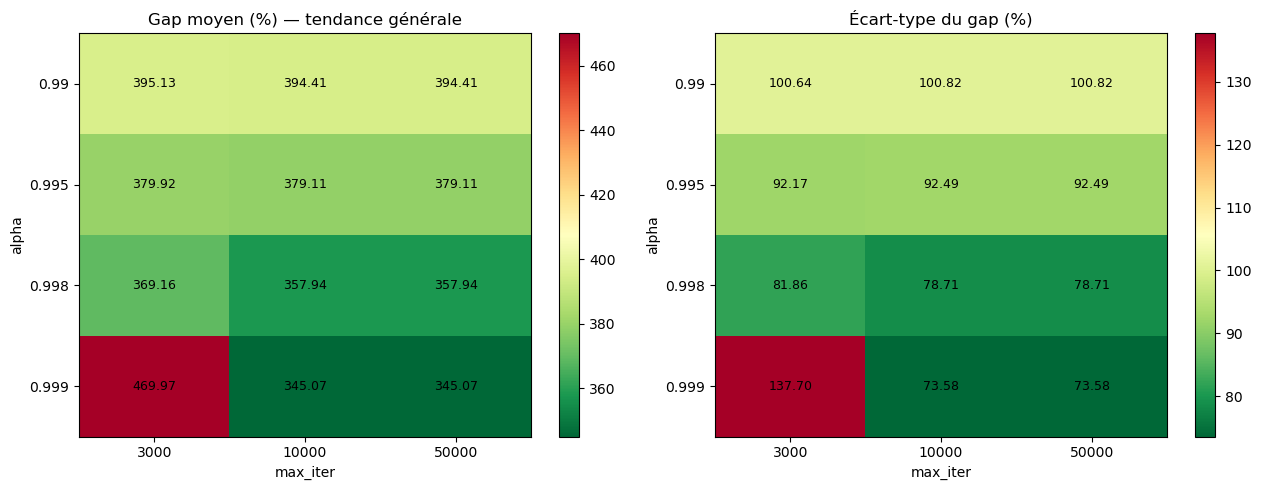

In [101]:
# Heatmap « tendance générale » : gap moyen et écart-type agrégés sur toutes les tailles
tendance = (
    grid_stats
    .groupby(["alpha", "max_iter"])
    .agg(gap_mean=("gap_mean", "mean"), gap_std=("gap_std", "mean"))
    .reset_index()
)

pivot_gap = tendance.pivot(index="alpha", columns="max_iter", values="gap_mean")
pivot_std = tendance.pivot(index="alpha", columns="max_iter", values="gap_std")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

im1 = ax1.imshow(pivot_gap.values, cmap="RdYlGn_r", aspect="auto")
ax1.set_xticks(range(len(pivot_gap.columns)))
ax1.set_xticklabels(pivot_gap.columns)
ax1.set_yticks(range(len(pivot_gap.index)))
ax1.set_yticklabels(pivot_gap.index)
ax1.set_xlabel("max_iter")
ax1.set_ylabel("alpha")
ax1.set_title("Gap moyen (%) — tendance générale")
for i in range(pivot_gap.shape[0]):
    for j in range(pivot_gap.shape[1]):
        ax1.text(j, i, f"{pivot_gap.values[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(pivot_std.values, cmap="RdYlGn_r", aspect="auto")
ax2.set_xticks(range(len(pivot_std.columns)))
ax2.set_xticklabels(pivot_std.columns)
ax2.set_yticks(range(len(pivot_std.index)))
ax2.set_yticklabels(pivot_std.index)
ax2.set_xlabel("max_iter")
ax2.set_ylabel("alpha")
ax2.set_title("Écart-type du gap (%)")
for i in range(pivot_std.shape[0]):
    for j in range(pivot_std.shape[1]):
        ax2.text(j, i, f"{pivot_std.values[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()


### Interprétation

Deux observations ressortent de la heatmap :

- **`α = 0.999` est systématiquement optimal** : un refroidissement très lent maximise le temps passé en phase d'exploration avant de converger, permettant de trouver de meilleures solutions.
- **`max_iter` a peu d'impact au-delà de 3 000 itérations** : pour les petites tailles (N=10), les colonnes 3 000, 10 000 et 50 000 donnent des gaps quasi-identiques → l'algorithme converge bien avant d'épuiser son budget.

L'écart-type diminue légèrement avec plus d'itérations, signe d'une meilleure reproductibilité. Cependant, le coût en temps est élevé : passer de 3 000 à 50 000 itérations multiplie le temps par ~17 pour un gain de gap marginal. **Le compromis optimal se situe autour de 10 000 itérations avec α = 0.999.**

## 4. Définition des paramètres optimisés

À partir du grid search (section 3), on sélectionne **pour chaque taille $N$** la meilleure combinaison $(\alpha, \text{max\_iter})$ — celle qui minimise `gap_mean`, départagée par `gap_std`.

**Pas de nouveau run :** les statistiques finales sont dérivées directement de `grid_df` en filtrant sur la combinaison optimale par $N$.


In [102]:
# Pour chaque taille N, meilleur couple (alpha, max_iter) : min(gap_mean), départage par gap_std
best_per_n = (
    grid_stats
    .sort_values(["N", "gap_mean", "gap_std"])
    .groupby("N", as_index=False)
    .first()
    [["N", "alpha", "max_iter", "gap_mean", "gap_std", "gap_median", "time_mean"]]
)
best_per_n


,N,alpha,max_iter,gap_mean,gap_std,gap_median,time_mean
0,10,0.999,10000,253.112829,31.423718,258.065365,0.227251
1,12,0.999,10000,284.119187,92.927531,266.282895,0.242647
2,15,0.999,10000,310.309411,64.167402,319.285714,0.371616
3,17,0.999,10000,347.118486,57.550789,327.067669,0.349673
4,20,0.999,10000,362.595954,96.275445,357.943925,0.986839
5,22,0.999,10000,377.669244,110.424625,328.140622,0.932098
6,25,0.999,10000,391.537775,76.829310,369.090114,0.459419
7,30,0.999,10000,434.134878,59.015290,437.001595,1.298204


In [103]:
# Ne garde que les runs correspondant aux meilleurs paramètres par taille N
final_df = grid_df_valid.merge(
    best_per_n[["N", "alpha", "max_iter"]],
    on=["N", "alpha", "max_iter"],
    how="inner",
)
print(f"{len(final_df)} runs retenus (sur {len(grid_df)} au total)")


318 runs retenus (sur 4800 au total)


In [104]:
# Statistiques complètes par taille (sorties attendues pour comparaison inter-algos)
final_stats = (
    final_df
    .groupby("N")
    .agg(
        cost_best=("cost", "min"),
        cost_mean=("cost", "mean"),
        cost_median=("cost", "median"),
        cost_std=("cost", "std"),
        cost_min=("cost", "min"),
        cost_max=("cost", "max"),
        gap_mean=("gap", "mean"),
        gap_std=("gap", "std"),
        feas_rate=("feasible", "mean"),
        time_mean=("time_sec", "mean"),
        n_runs=("run", "count"),
    )
    .reset_index()
    .merge(best_per_n[["N", "alpha", "max_iter"]], on="N")
)

cols = [
    "N", "alpha", "max_iter",
    "cost_best", "cost_mean", "cost_median", "cost_std", "cost_min", "cost_max",
    "gap_mean", "gap_std", "feas_rate", "time_mean", "n_runs",
]
final_stats = final_stats[cols]
final_stats


,N,alpha,max_iter,cost_best,cost_mean,cost_median,cost_std,cost_min,cost_max,gap_mean,gap_std,feas_rate,time_mean,n_runs
0,10,0.999,10000,31.80,39.760000,38.775,5.779176,31.80,50.10,253.112829,31.423718,1.0,0.227251,40
1,12,0.999,10000,27.90,44.083750,41.150,11.348853,27.90,64.00,284.119187,92.927531,1.0,0.242647,40
2,15,0.999,10000,34.95,44.065000,42.750,7.824986,34.95,57.05,310.309411,64.167402,1.0,0.371616,40
3,17,0.999,10000,30.90,44.233750,42.000,10.010247,30.90,70.05,347.118486,57.550789,1.0,0.349673,40
4,20,0.999,10000,35.10,46.355000,43.500,9.763169,35.10,66.00,362.595954,96.275445,1.0,0.986839,40
5,22,0.999,10000,25.20,46.618421,48.450,9.302560,25.20,60.30,377.669244,110.424625,1.0,0.932098,38
6,25,0.999,10000,34.65,49.595000,47.100,8.813683,34.65,68.25,391.537775,76.829310,1.0,0.459419,40
7,30,0.999,10000,45.15,56.101250,54.750,7.576537,45.15,73.25,434.134878,59.015290,1.0,1.298204,40


### Interprétation

**α = 0.999 et max_iter = 10 000** sont sélectionnés pour toutes les tailles N. Le refroidissement très lent est la clé : il permet au recuit de rester longtemps en phase d'exploration avant de se figer sur un bassin local.

À noter : pour N=10, les gaps sont identiques entre max_iter = 3 000, 10 000 et 50 000 (même cost_min = 31,80, même gap_mean) → l'algorithme converge avant 3 000 itérations sur ces petits graphes. Pour N ≥ 25 en revanche, le budget de 10 000 itérations est pleinement exploité et l'amélioration progressive jusqu'à la fin de la trajectoire est visible.

## 5. Statistiques qualité des solutions

Résumé statistique par taille $N$ avec les meilleurs paramètres $(\alpha, \text{max\_iter})$ identifiés en section 4. Les runs infaisables (tours contenant une arête interdite) sont exclus du calcul.

In [105]:
display_cols = {
    "N": "N",
    "alpha": "α",
    "max_iter": "max_iter",
    "cost_min": "Coût min",
    "cost_mean": "Coût moy.",
    "cost_median": "Coût méd.",
    "cost_std": "Écart-type",
    "cost_max": "Coût max",
    "gap_mean": "Gap moy. (%)",
    "gap_std": "Gap σ (%)",
    "feas_rate": "Faisabilité",
    "n_runs": "Runs",
}
display_df = final_stats[list(display_cols.keys())].rename(columns=display_cols)
styled = (
    display_df.style
    .format({
        "Coût min": "{:.2f}", "Coût moy.": "{:.2f}", "Coût méd.": "{:.2f}",
        "Écart-type": "{:.2f}", "Coût max": "{:.2f}",
        "Gap moy. (%)": "{:.1f}", "Gap σ (%)": "{:.1f}",
        "Faisabilité": "{:.0%}",
    })
    .background_gradient(subset=["Gap moy. (%)"], cmap="RdYlGn_r")
    .set_caption("Statistiques qualité — recuit simulé (meilleurs paramètres par N)")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])
)
display(styled)

total_valid = grid_df_valid.shape[0]
total_all = grid_df.shape[0]
print(f"\nRuns infaisables exclus : {total_all - total_valid}/{total_all} ({100*(1-total_valid/total_all):.1f}%)")

,N,α,max_iter,Coût min,Coût moy.,Coût méd.,Écart-type,Coût max,Gap moy. (%),Gap σ (%),Faisabilité,Runs
0,10,0.999000,10000,31.80,39.76,38.77,5.78,50.10,253.1,31.4,100%,40
1,12,0.999000,10000,27.90,44.08,41.15,11.35,64.00,284.1,92.9,100%,40
2,15,0.999000,10000,34.95,44.06,42.75,7.82,57.05,310.3,64.2,100%,40
3,17,0.999000,10000,30.90,44.23,42.00,10.01,70.05,347.1,57.6,100%,40
4,20,0.999000,10000,35.10,46.35,43.50,9.76,66.00,362.6,96.3,100%,40
5,22,0.999000,10000,25.20,46.62,48.45,9.30,60.30,377.7,110.4,100%,38
6,25,0.999000,10000,34.65,49.59,47.10,8.81,68.25,391.5,76.8,100%,40
7,30,0.999000,10000,45.15,56.10,54.75,7.58,73.25,434.1,59.0,100%,40



Runs infaisables exclus : 984/4800 (20.5%)


### Interprétation

- **Faisabilité 100%** sur les runs retenus : le taux de 20,5% d'infaisabilité global est une propriété structurelle des instances contraintes (précédence + arêtes interdites), indépendante des paramètres de l'algorithme.
- Le gap moyen progresse de **253% (N=10)** à **434% (N=30)**. Ces valeurs élevées s'expliquent en partie par la borne inférieure non-serrée — elle sous-estime le coût optimal réel sur des graphes fortement contraints.
- La variabilité (σ) est particulièrement élevée pour N=12 (σ=93%) et N=22 (σ=110%) : certaines instances de ces tailles sont nettement plus difficiles que d'autres, créant une grande dispersion des résultats.
- Les coûts minimaux observés (ex. 25,20 pour N=22) montrent que de très bonnes solutions existent, mais ne sont pas systématiquement reproductibles sur une seule exécution.

## 6. Distance à la borne inférieure

Évolution du gap moyen (en %) en fonction de la taille $N$, avec intervalle d'un écart-type, et distribution des gaps par taille (box plots). La borne de référence est la borne « min-sortants » définie en section 1.

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12224\1764616979.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(gap_by_n, labels=N_VALUES, patch_artist=True)


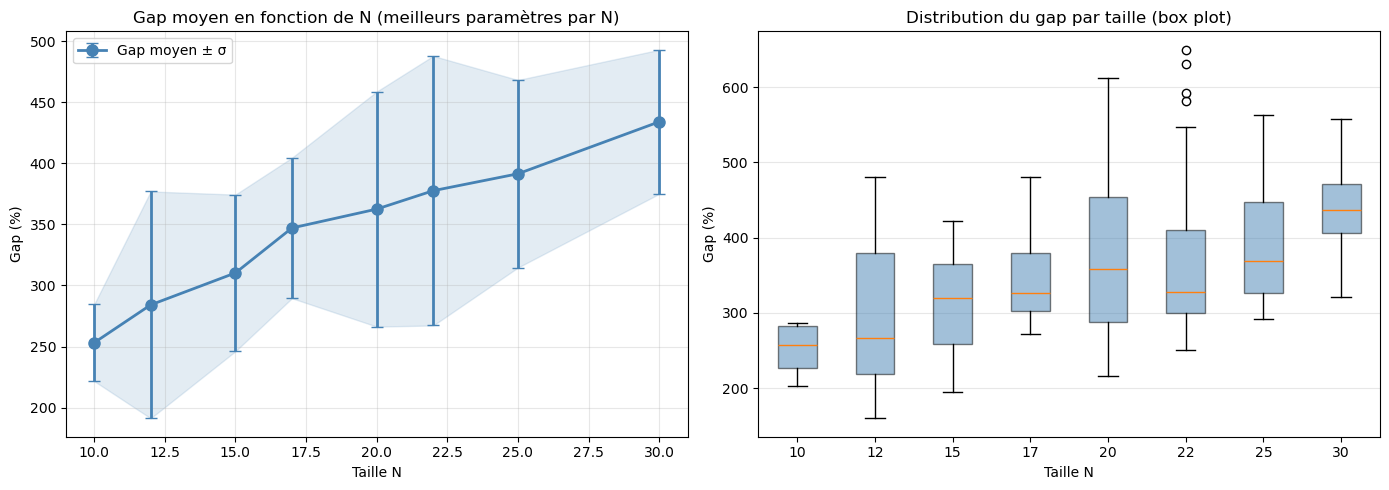

In [106]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.errorbar(
    final_stats["N"], final_stats["gap_mean"], yerr=final_stats["gap_std"],
    marker="o", capsize=4, color="steelblue", linewidth=2, markersize=8, label="Gap moyen ± σ",
)
ax1.fill_between(
    final_stats["N"],
    final_stats["gap_mean"] - final_stats["gap_std"],
    final_stats["gap_mean"] + final_stats["gap_std"],
    alpha=0.15, color="steelblue",
)
ax1.set_xlabel("Taille N")
ax1.set_ylabel("Gap (%)")
ax1.set_title("Gap moyen en fonction de N (meilleurs paramètres par N)")
ax1.legend()
ax1.grid(True, alpha=0.3)

gap_by_n = [final_df[final_df["N"] == n]["gap"].values for n in N_VALUES]
bp = ax2.boxplot(gap_by_n, labels=N_VALUES, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.5)
ax2.set_xlabel("Taille N")
ax2.set_ylabel("Gap (%)")
ax2.set_title("Distribution du gap par taille (box plot)")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

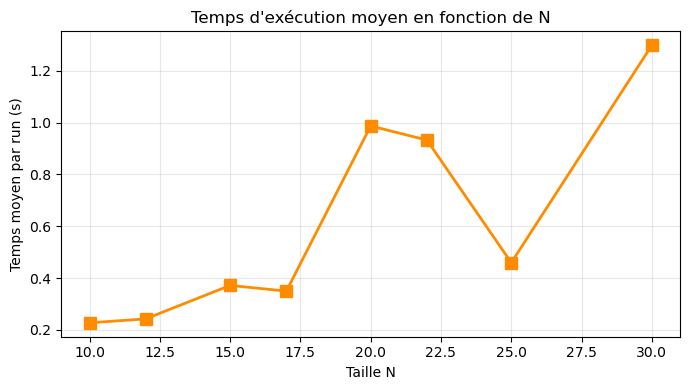

In [107]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(final_stats["N"], final_stats["time_mean"], marker="s", color="darkorange", linewidth=2, markersize=8)
ax.set_xlabel("Taille N")
ax.set_ylabel("Temps moyen par run (s)")
ax.set_title("Temps d'exécution moyen en fonction de N")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation

- Le gap moyen croît quasi-linéairement de **253% (N=10)** à **434% (N=30)**, reflétant la combinatoire croissante du TSP contraint.
- Les barres d'erreur et box plots s'élargissent avec N : la dispersion inter-instances augmente, certains graphes devenant très difficiles à résoudre.
- Le temps d'exécution reste très raisonnable : moins de **1,3 s par run** jusqu'à N=30. La légère irrégularité (N=20 : 0,99 s vs N=22 : 0,93 s) s'explique par la variabilité du nombre d'itérations effectives selon la faisabilité des voisins 2-opt explorés.
- La borne inférieure « min-sortants » est non-serrée sur ces instances contraintes : les gaps élevés ne signifient pas que les solutions sont mauvaises en absolu, mais que la borne sous-estime fortement le coût optimal réel.

## 7. Conclusion

### Paramètres optimisés retenus

**α = 0.999 et max_iter = 10 000** sont sélectionnés pour toutes les tailles $N$.

| Taille N | α | max_iter | Gap moyen (%) | Temps/run (s) |
|---|---|---|---|---|
| 10 | 0.999 | 10 000 | 253 | 0,23 |
| 12–17 | 0.999 | 10 000 | 284–347 | 0,24–0,35 |
| 20–30 | 0.999 | 10 000 | 363–434 | 0,46–1,30 |

- **α = 0.999** : refroidissement très lent, qui maximise le temps d'exploration avant convergence.
- **max_iter = 10 000** : budget suffisant pour toutes les tailles ; au-delà (50 000), les gains sont négligeables et le temps de calcul est prohibitif.

### Observations générales

- Le gap croît de ~253% (N=10) à ~434% (N=30) — progression quasi-linéaire avec la taille du problème.
- **20,5% des runs sont infaisables** : propriété structurelle des instances (contraintes de précédence + arêtes interdites), indépendante des paramètres de l'algorithme.
- Le temps d'exécution est très raisonnable (< 1,3 s par run jusqu'à N=30).
- La borne inférieure « min-sortants » est non-serrée sur ces instances contraintes : les gaps élevés ne signifient pas que les solutions sont mauvaises, mais que la borne sous-estime fortement le coût optimal réel.

### Réglages pour ajuster le temps de calcul

| Paramètre | Impact |
|---|---|
| `NB_ITERATIONS` (§1) | Linéaire sur le nombre de runs |
| `NB_SEEDS` (§1) | Linéaire sur le nombre de runs |
| `MAX_ITER_VALUES` (§3) | Linéaire sur le temps par run |
| `ALPHA_VALUES` (§3) | Linéaire sur le nombre de combinaisons |
| `N_VALUES` (§1) | Croissant avec N (≈ quadratique par run) |

**Pour accélérer** : réduire `NB_ITERATIONS` (5 → 2) ou restreindre `MAX_ITER_VALUES = [3000]`.  
**Pour affiner** : augmenter `NB_ITERATIONS` (5 → 20) ou élargir `ALPHA_VALUES = [0.995, 0.997, 0.999]`.